# Pixel-level bound tightness vs semantic regions



Min bound width: 0.2
Max bound width: 0.4


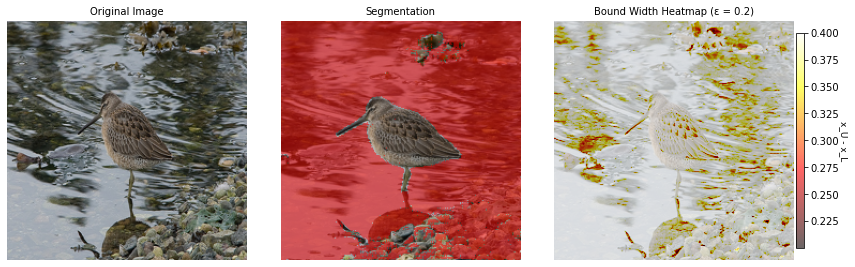

Saved to bound_width_visualization.pdf


In [26]:
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt

import torchvision

# ----------------------------
# Config
# ----------------------------
device = "cpu"
eps = 0.2
img_path = "../benchmarks/vggnet16_benchmark2022/imagenet-sample/n02033041_dowitcher.JPEG"

# ----------------------------
# Preprocess
# ----------------------------
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

def preprocess_pil(pil_img):
    pil_img = pil_img.convert("RGB").resize((256, 256))
    left = (256 - 224)//2
    top  = (256 - 224)//2
    pil_img = pil_img.crop((left, top, left+224, top+224))

    x = torch.from_numpy(np.array(pil_img)).float().to(device) / 255.0
    x = x.permute(2,0,1).unsqueeze(0)
    x_norm = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x, x_norm, pil_img

pil = Image.open(img_path)
x_01, x_norm, pil_crop = preprocess_pil(pil)

# ----------------------------
# Input perturbation bounds
# ----------------------------
mask = torch.ones((1,1,224,224), dtype=torch.float32, device=device)

lb_01 = torch.clamp(x_01 - eps * mask, 0.0, 1.0)
ub_01 = torch.clamp(x_01 + eps * mask, 0.0, 1.0)

# Heatmap = average width across RGB channels
heat = (ub_01 - lb_01).mean(dim=1).squeeze(0).detach().cpu().numpy()

print("Min bound width:", heat.min())
print("Max bound width:", heat.max())

import matplotlib.pyplot as plt
from PIL import Image

# Load segmentation image
seg_path = "/home/z.dehghanipour/XAIV/benchmarks/vggnet16_benchmark2022_segmented_one_img/debug_vis/n02033041_dowitcher_seg0_score_0.810.png"
pil_seg = Image.open(seg_path)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(
    1, 3,
    figsize=(11.5, 4),                 # <<< IMPORTANT: reduce width
    gridspec_kw={"wspace": 0.02}       # small gap
)

# Original
axes[0].imshow(pil_crop)
axes[0].set_title("Original Image", fontsize=10)
axes[0].axis("off")

# Segmentation
axes[1].imshow(pil_seg)
axes[1].set_title("Segmentation", fontsize=10)
axes[1].axis("off")

# Heatmap
axes[2].imshow(pil_crop)
im = axes[2].imshow(heat, cmap="hot", alpha=0.6)
axes[2].set_title(f"Bound Width Heatmap (ε = {eps})", fontsize=10)
axes[2].axis("off")

# Inset colorbar (doesn't push layout)
cax = inset_axes(axes[2], width="3%", height="90%", loc="center right", borderpad=-1)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("x_U - x_L", rotation=270, labelpad=9, fontsize=9)

# Tight margins
fig.subplots_adjust(left=0.01, right=0.995, top=0.88, bottom=0.05, wspace=0.02)

output_path = "bound_width_visualization.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {output_path}")